<a href="https://colab.research.google.com/github/MaryamAli-2020/Ajman_Data_Inisights_Generator/blob/main/Data_Mining_Assignment_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [1]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import HistGradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

## Reading the dataset

In [3]:
# read the dataset
df = pd.read_csv('/content/loan_approval_dataset.csv')
display(df.head())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
print("1. DATA EXPLORATION")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn info:")
print(df.info())

1. DATA EXPLORATION
--------------------------------------------------
Dataset shape: (4269, 13)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_s

## **Data Pre-processing**

In [5]:
df.columns = df.columns.str.strip() #remove space in colums

for columX in df.select_dtypes(include=['object']).columns: #remove space in rows
    df[columX] = df[columX].str.strip()

In [6]:
# make all columX object=text to lowercase
for columX in df.select_dtypes(include=['object']).columns:
    df[columX] = df[columX].str.lower()

# Loop through object=text and remove special character
for columX in df.select_dtypes(include=['object']).columns:
    df[columX] = df[columX].str.replace('*', '', regex=False)
    df[columX] = df[columX].str.replace('"', '', regex=False)
    df[columX] = df[columX].str.replace("'", '', regex=False)
    df[columX] = df[columX].str.replace('>', '', regex=False)
    df[columX] = df[columX].str.replace('<', '', regex=False)


In [7]:
display(df.head())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,graduate,no,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
1,2,0,not graduate,yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected
2,3,3,graduate,no,9100000,29700000,20,506,7100000,4500000,33300000,12800000,rejected
3,4,3,graduate,no,8200000,30700000,8,467,18200000,3300000,23300000,7900000,rejected
4,5,5,not graduate,yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,rejected


In [8]:
df['self_employed'] = df['self_employed'].replace({'yes': 1, 'no': 0}) #replace yes and no with 1&0s
df['education'] = df['education'].replace({'graduate': 1, 'not graduate': 0}) #same appove
df['loan_status'] = df['loan_status'].replace({'approved': 1, 'rejected': 0}) #same appove

In [9]:
display(df.head())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [10]:
#check for missing values in each column
missing_values = df.isnull().sum()

display(missing_values)

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [11]:
df = df.drop_duplicates(subset=['loan_id'], keep='first') #remove any duplicates using the ID value

df = df.dropna() #remove rows with any missing data

In [12]:
df = df.drop(columns=['loan_id']) #dropp unnecessary ID column

In [13]:
df.shape #to see if any chnage happened or not

(4269, 12)

### **Feature Engineering**

In [14]:
# Financial ratios - these are powerful features for loan prediction
df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']
df['total_assets'] = (df['residential_assets_value'] +
                           df['commercial_assets_value'] +
                           df['luxury_assets_value'] +
                           df['bank_asset_value'])
df['loan_to_assets_ratio'] = df['loan_amount'] / df['total_assets']
df['income_per_dependent'] = df['income_annum'] / (df['no_of_dependents'] + 1)
df['asset_diversity'] = ((df['residential_assets_value'] > 0).astype(int) +
                              (df['commercial_assets_value'] > 0).astype(int) +
                              (df['luxury_assets_value'] > 0).astype(int) +
                              (df['bank_asset_value'] > 0).astype(int))


In [15]:
# CIBIL score categories (domain knowledge)
def categorize_cibil(score):
    if score >= 750: return 1
    elif score >= 700: return 2
    elif score >= 650: return 3
    else: return 4

df['cibil_category'] = df['cibil_score'].apply(categorize_cibil)

In [16]:
print(f"New features created: {['loan_to_income_ratio', 'total_assets', 'loan_to_assets_ratio', 'income_per_dependent', 'asset_diversity', 'cibil_category']}")

New features created: ['loan_to_income_ratio', 'total_assets', 'loan_to_assets_ratio', 'income_per_dependent', 'asset_diversity', 'cibil_category']


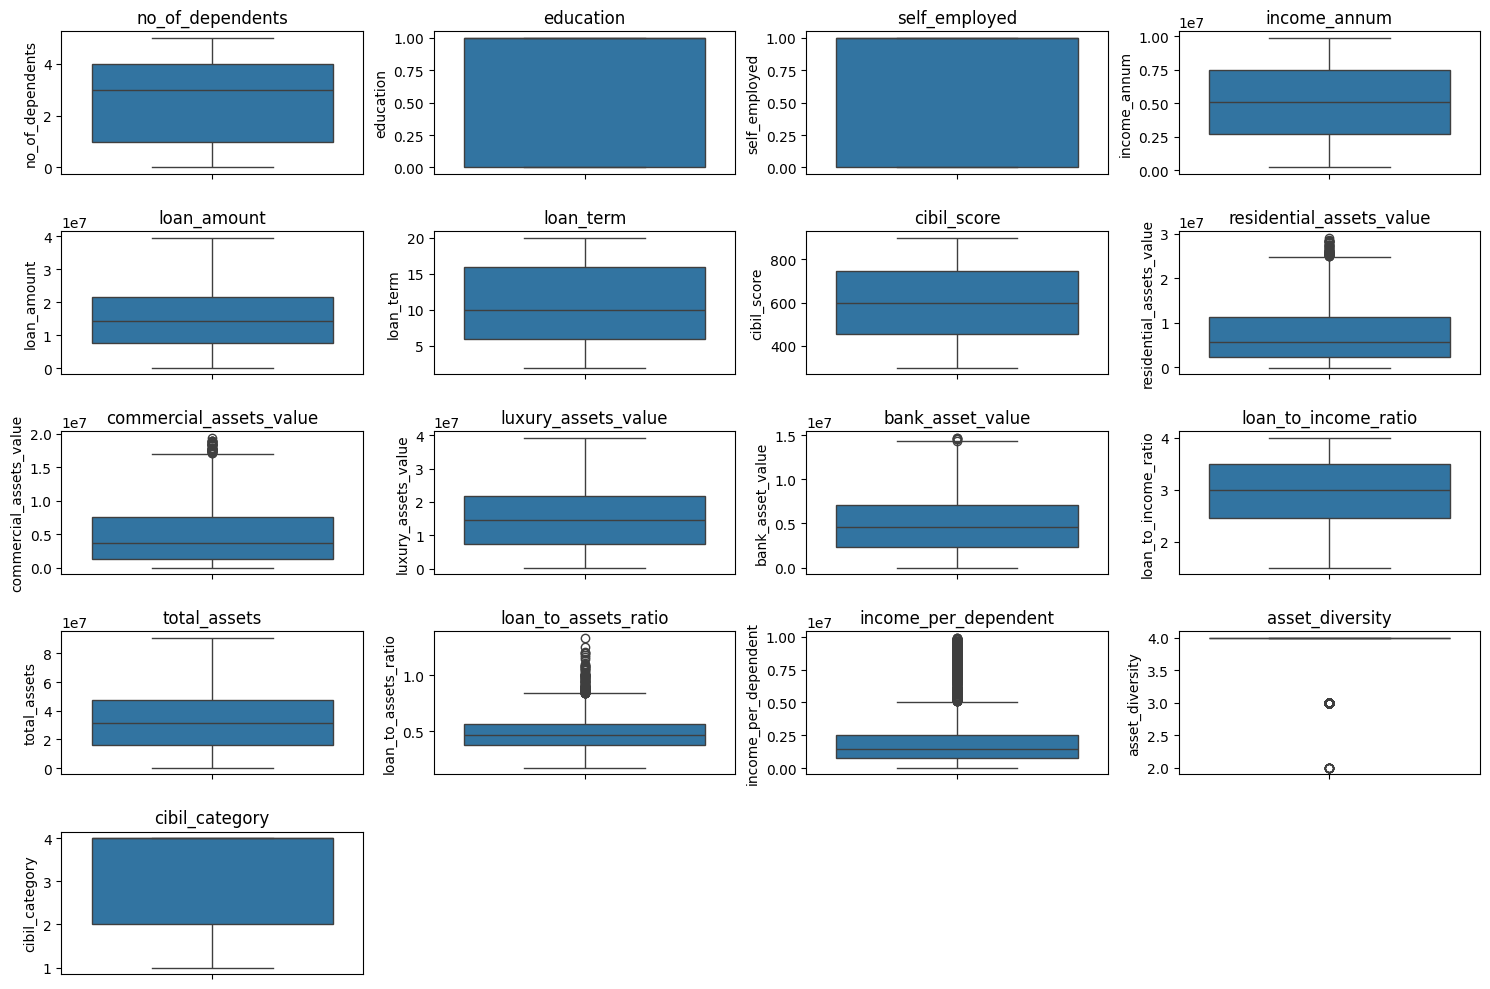

In [17]:
# Select only the numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude the target variable if it's not relevant for outlier analysis
if 'loan_status' in numerical_cols:
    numerical_cols = numerical_cols.drop('loan_status')

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [18]:
# Outlier detection using IQR method
def detect_outliers(df, columns):
    outlier_indices = set()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
    return list(outlier_indices)

numerical_cols = ['income_annum', 'loan_amount', 'cibil_score', 'loan_to_income_ratio', 'total_assets']
outlier_indices = detect_outliers(df, numerical_cols)
print(f"Outliers detected: {len(outlier_indices)} rows")

Outliers detected: 0 rows


In [19]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_to_income_ratio,total_assets,loan_to_assets_ratio,income_per_dependent,asset_diversity,cibil_category
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.114583,50700000,0.589744,3.200000e+06,4,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.975610,17000000,0.717647,4.100000e+06,4,4
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.263736,57700000,0.514731,2.275000e+06,4,4
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.743902,52700000,0.582543,2.050000e+06,4,4
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.469388,55000000,0.440000,1.633333e+06,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,2.300000,7400000,0.310811,1.666667e+05,4,4
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,3.424242,20000000,0.565000,3.300000e+06,4,4
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,3.676923,39000000,0.612821,2.166667e+06,4,4
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,3.121951,28800000,0.444444,2.050000e+06,4,1


### **Standardizing the Columns**

In [23]:
# Encode categorical variables
le_education = LabelEncoder()
le_employed = LabelEncoder()
le_cibil_cat = LabelEncoder()
le_target = LabelEncoder()

df['education_encoded'] = le_education.fit_transform(df['education'])
df['self_employed_encoded'] = le_employed.fit_transform(df['self_employed'])
df['cibil_category_encoded'] = le_cibil_cat.fit_transform(df['cibil_category'])
df['loan_status_encoded'] = le_target.fit_transform(df['loan_status'])

print("Categorical encoding completed")

Categorical encoding completed


In [24]:
# Select features for modeling
feature_columns = ['no_of_dependents', 'education_encoded', 'self_employed_encoded',
                  'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
                  'residential_assets_value', 'commercial_assets_value',
                  'luxury_assets_value', 'bank_asset_value',
                  'loan_to_income_ratio', 'total_assets', 'loan_to_assets_ratio',
                  'income_per_dependent', 'asset_diversity', 'cibil_category_encoded']

X = df[feature_columns]
y = df['loan_status_encoded']

print(f"Features selected: {len(feature_columns)}")
print(f"Feature names: {feature_columns}")

Features selected: 17
Feature names: ['no_of_dependents', 'education_encoded', 'self_employed_encoded', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_to_income_ratio', 'total_assets', 'loan_to_assets_ratio', 'income_per_dependent', 'asset_diversity', 'cibil_category_encoded']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
# Scale features (important for some models)
scaler = RobustScaler()  # More robust to outliers than StandardScaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (3415, 17), Test set: (854, 17)


In [29]:
X_train_scaled

array([[ 0.33333333,  0.        , -1.        , ..., -0.28488372,
        -1.        , -1.5       ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.33333333,  0.        ,  0.        , ...,  0.72674419,
         0.        , -1.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.07267442,
         0.        ,  0.        ],
       [-1.        ,  0.        , -1.        , ...,  1.71511628,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.        , ...,  0.43604651,
         0.        ,  0.        ]])

In [30]:
X_test_scaled

array([[ 0.        , -1.        ,  0.        , ...,  0.36337209,
         0.        , -0.5       ],
       [ 0.33333333, -1.        ,  0.        , ..., -0.48255814,
         0.        ,  0.        ],
       [-0.66666667,  0.        , -1.        , ...,  1.48255814,
         0.        ,  0.        ],
       ...,
       [ 0.33333333,  0.        ,  0.        , ..., -0.29651163,
         0.        ,  0.        ],
       [ 0.66666667,  0.        , -1.        , ..., -0.81395349,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.30523256,
         0.        ,  0.        ]])

In [28]:
# count the occurrences of each value in the 'loan_status' column
loan_status_counts = df['loan_status'].value_counts()

display(loan_status_counts)

,count
loan_status,
1,2656
0,1613


## **Data Processing**

### **Models**

In [31]:
models = {
    'LightGBM': lgb.LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        num_leaves=31,
        learning_rate=0.05,
        feature_fraction=0.9,
        bagging_fraction=0.8,
        bagging_freq=5,
        verbose=-1,
        random_state=42
    ),

    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ),

    'CatBoost': CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        bootstrap_type='Bernoulli',
        subsample=0.8,
        random_seed=42,
        verbose=False
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=1000,
        max_depth=6,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42
    )
}

In [32]:
# Train and evaluate models
results = {}
cv_scores = {}

print("Training models...")
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for HistGradientBoosting, original for tree-based models
    if name == 'HistGradientBoosting':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        # Cross-validation
        cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        # Cross-validation
        cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate metrics
    auc_score = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'auc_score': auc_score,
        'cv_mean': cv_score.mean(),
        'cv_std': cv_score.std()
    }

    print(f"{name} - AUC: {auc_score:.4f}, CV Score: {cv_score.mean():.4f} (+/- {cv_score.std()*2:.4f})")

Training models...

Training LightGBM...
LightGBM - AUC: 1.0000, CV Score: 0.9993 (+/- 0.0028)

Training XGBoost...
XGBoost - AUC: 1.0000, CV Score: 0.9992 (+/- 0.0033)

Training CatBoost...
CatBoost - AUC: 1.0000, CV Score: 0.9998 (+/- 0.0008)

Training HistGradientBoosting...
HistGradientBoosting - AUC: 1.0000, CV Score: 0.9999 (+/- 0.0001)


### **Evaluation**

In [36]:
# Detailed evaluation for each model
for name, result in results.items():
    print(f"\n{name} Detailed Results:")
    print("-" * 30)
    print("Classification Report:")
    # Convert the numpy array of integer class labels to a list of strings
    target_names_str = [str(cls) for cls in le_target.classes_]
    print(classification_report(y_test, result['predictions'],
                              target_names=target_names_str))

    # Feature importance (for tree-based models)
    if hasattr(result['model'], 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': feature_columns,
            'importance': result['model'].feature_importances_
        }).sort_values('importance', ascending=False)

        print("\nTop 10 Important Features:")
        print(feature_importance.head(10).to_string(index=False))


LightGBM Detailed Results:
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854


Top 10 Important Features:
                 feature  importance
    loan_to_assets_ratio         717
    loan_to_income_ratio         438
             cibil_score         287
 commercial_assets_value         234
residential_assets_value         196
    income_per_dependent         188
             loan_amount         170
               loan_term         167
        bank_asset_value         148
            total_assets         118

XGBoost Detailed Results:
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1

In [37]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC Score': [results[name]['auc_score'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
}).sort_values('AUC Score', ascending=False)

print("Model Performance Ranking:")
print(comparison_df.to_string(index=False, float_format='%.4f'))

Model Performance Ranking:
               Model  AUC Score  CV Mean  CV Std
            LightGBM     1.0000   0.9993  0.0014
            CatBoost     1.0000   0.9998  0.0004
             XGBoost     1.0000   0.9992  0.0016
HistGradientBoosting     1.0000   0.9999  0.0001


In [38]:
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"AUC Score: {results[best_model_name]['auc_score']:.4f}")
print(f"Cross-validation: {results[best_model_name]['cv_mean']:.4f} (+/- {results[best_model_name]['cv_std']*2:.4f})")


🏆 BEST PERFORMING MODEL: LightGBM
AUC Score: 1.0000
Cross-validation: 0.9993 (+/- 0.0028)
